# 10 — Evaluación de Privacidad

**Fase 3 — Evaluación [OE 5]**  
Cuantifica el riesgo de privacidad de cada dataset sintético mediante tres métricas complementarias:

1. **DCR** (Distance to Closest Record): distancia euclídea de cada muestra sintética a su vecino
   real más cercano. Valores muy pequeños indican posible copia de registros reales.
2. **NNDR** (Nearest Neighbor Distance Ratio): ratio d(NN1)/d(NN2). Valores cercanos a 0 señalan
   que una muestra sintética está casi "pegada" a un único registro real (memorización).
3. **MIA** (Membership Inference Advantage): fracción de muestras sintéticas más cercanas al
   conjunto de referencia de entrenamiento que al holdout, menos 0,5. Valor 0 = privacidad perfecta.

Nota sobre el diseño: los generadores se entrenaron sobre el dataset COMPLETO (22 520 muestras).
La partición 80/20 se usa únicamente como proxy para distinguir "datos vistos" de "datos no vistos"
durante el cálculo de ventaja MIA. Las distancias DCR y NNDR se computan siempre contra el
dataset real completo.

Referencia metodológica: Platzer y Reutterer (2021), Jordon et al. (2022).

## 0. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
SYNTHETIC = ROOT / 'data' / 'synthetic'
REPORTS   = ROOT / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'Holdout real':  'dimgray',
    'CTGAN':         'tomato',
    'TVAE':          'seagreen',
    'TabDDPM':       'steelblue',
    'DP-CTGAN ε=∞':  'mediumpurple',
    'DP-CTGAN ε=10': 'darkorchid',
    'DP-CTGAN ε=5':  'purple',
    'DP-CTGAN ε=1':  'indigo',
}

# Submuestra para distancias (O(n²)). 3000 es suficiente para estimaciones estables.
N_SUB = 3000

print('Entorno listo.')

Entorno listo.


## 1. Carga de datos

In [2]:
real   = pd.read_parquet(PROCESSED / 'tabular_48h.parquet')
TARGET = 'hospital_expire_flag'
id_cols = [c for c in real.columns if c.endswith('_id')]
feat_cols = [c for c in real.columns
             if c not in id_cols + [TARGET] and real[c].dtype != object]

print(f'Dataset real: {real.shape}  |  features: {len(feat_cols)}')

X_real = real[feat_cols].fillna(0).values.astype(np.float32)
y_real = real[TARGET].values.astype(int)

# Partición proxy — mismo random_state que nb09 para coherencia
idx_all = np.arange(len(X_real))
idx_train, idx_holdout = train_test_split(
    idx_all, test_size=0.2, stratify=y_real, random_state=42
)
X_ref_train   = X_real[idx_train]    # 18 016 — proxy de "datos vistos"
X_ref_holdout = X_real[idx_holdout]  #  4 504 — proxy de "datos no vistos"

print(f'Referencia train:   {X_ref_train.shape}')
print(f'Referencia holdout: {X_ref_holdout.shape}')

SYNTH_FILES = {
    'CTGAN':         SYNTHETIC / 'ctgan_samples.parquet',
    'TVAE':          SYNTHETIC / 'tvae_samples.parquet',
    'TabDDPM':       SYNTHETIC / 'tabddpm_samples.parquet',
    'DP-CTGAN ε=∞':  SYNTHETIC / 'dp_ctgan_εinf_samples.parquet',
    'DP-CTGAN ε=10': SYNTHETIC / 'dp_ctgan_ε10_samples.parquet',
    'DP-CTGAN ε=5':  SYNTHETIC / 'dp_ctgan_ε5_samples.parquet',
    'DP-CTGAN ε=1':  SYNTHETIC / 'dp_ctgan_ε1_samples.parquet',
}

synth = {}
print()
for name, path in SYNTH_FILES.items():
    if path.exists():
        df = pd.read_parquet(path)
        synth[name] = df
        print(f'  [OK] {name:<20} {df.shape}')
    else:
        print(f'  [--] {name:<20} (no encontrado)')

Dataset real: (22520, 127)  |  features: 121
Referencia train:   (18016, 121)
Referencia holdout: (4504, 121)

  [OK] CTGAN                (22520, 127)
  [OK] TVAE                 (22520, 127)
  [OK] TabDDPM              (22520, 126)
  [OK] DP-CTGAN ε=∞         (22520, 126)
  [OK] DP-CTGAN ε=10        (22520, 126)
  [OK] DP-CTGAN ε=5         (22520, 126)
  [OK] DP-CTGAN ε=1         (22520, 126)


## 2. Preprocesamiento — normalización para distancias

Las métricas de distancia son sensibles a la escala de las variables. Un StandardScaler ajustado
sobre el conjunto de referencia de entrenamiento garantiza que variables con rangos muy distintos
(p.ej. edad 18-90 vs. frecuencia cardíaca 30-200 vs. lactato 0-20) contribuyen equitativamente
al cómputo de distancias.

In [3]:
scaler = StandardScaler()
scaler.fit(X_ref_train)

X_ref_train_s   = scaler.transform(X_ref_train).astype(np.float32)
X_ref_holdout_s = scaler.transform(X_ref_holdout).astype(np.float32)
X_real_s        = scaler.transform(X_real).astype(np.float32)  # dataset completo (referencia DCR)


def scale_synth(df_s, feat_cols, scaler):
    """Construye y escala la matriz de features para un dataset sintético,
    rellenando con 0 las columnas ausentes."""
    cols_s = [c for c in feat_cols if c in df_s.columns]
    X_s    = df_s[cols_s].fillna(0).values.astype(np.float32)
    if len(cols_s) < len(feat_cols):
        X_full = np.zeros((len(X_s), len(feat_cols)), dtype=np.float32)
        idx    = [feat_cols.index(c) for c in cols_s]
        X_full[:, idx] = X_s
        X_s = X_full
    return scaler.transform(X_s).astype(np.float32)


synth_scaled = {}
for name, df_s in synth.items():
    synth_scaled[name] = scale_synth(df_s, feat_cols, scaler)

print('Normalización completada. Referencia: StandardScaler ajustado sobre X_ref_train.')
print(f'Media ~0, std ~1 sobre features del training reference.')

Normalización completada. Referencia: StandardScaler ajustado sobre X_ref_train.
Media ~0, std ~1 sobre features del training reference.


## 3. DCR — Distance to Closest Record

Para cada muestra sintética $s$, se computa la distancia euclídea normalizada a su vecino
más cercano en el dataset real completo:
$$\text{DCR}(s) = \min_{r \in \mathcal{D}_{\text{real}}} \|s - r\|_2$$

La distribución de referencia se obtiene calculando el DCR de las muestras del holdout
respecto al training. Si el DCR sintético es sistemáticamente menor que el DCR de referencia,
los datos sintéticos están más cerca de los registros reales de lo esperado para datos nuevos
de la misma distribución, lo que indica riesgo de memorización.

In [4]:
def compute_dcr(X_query, X_reference, n_sub=N_SUB, seed=42):
    """Distancia al vecino más cercano de X_query en X_reference."""
    rng = np.random.default_rng(seed)
    if len(X_query) > n_sub:
        idx = rng.choice(len(X_query), n_sub, replace=False)
        X_query = X_query[idx]
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', n_jobs=-1)
    nn.fit(X_reference)
    dist, _ = nn.kneighbors(X_query)
    return dist[:, 0]


# Referencia: DCR de muestras reales del holdout al training
dcr_holdout = compute_dcr(X_ref_holdout_s, X_ref_train_s)

print('=== DCR — Distance to Closest Record ===\n')
print(f'  Holdout real (referencia)')
print(f'    mediana={np.median(dcr_holdout):.4f}  media={np.mean(dcr_holdout):.4f}  '
      f'p5={np.percentile(dcr_holdout,5):.4f}  p25={np.percentile(dcr_holdout,25):.4f}\n')

dcr_results = {}
for name, X_s in synth_scaled.items():
    # DCR sintético respecto al dataset real completo
    dcr = compute_dcr(X_s, X_real_s)
    dcr_results[name] = dcr
    ratio = np.median(dcr) / np.median(dcr_holdout)
    pct_below_p5 = (dcr < np.percentile(dcr_holdout, 5)).mean() * 100
    print(f'  {name:<20}  mediana={np.median(dcr):.4f}  p5={np.percentile(dcr,5):.4f}  '
          f'ratio={ratio:.3f}  % bajo p5 holdout={pct_below_p5:.1f}%')

=== DCR — Distance to Closest Record ===

  Holdout real (referencia)
    mediana=7.3533  media=7.6886  p5=4.9200  p25=6.2240

  CTGAN                 mediana=9.4670  p5=6.7929  ratio=1.287  % bajo p5 holdout=0.0%
  TVAE                  mediana=6.7817  p5=4.8106  ratio=0.922  % bajo p5 holdout=6.0%
  TabDDPM               mediana=126.3761  p5=87.8109  ratio=17.186  % bajo p5 holdout=0.0%
  DP-CTGAN ε=∞          mediana=8.5892  p5=5.3818  ratio=1.168  % bajo p5 holdout=2.0%
  DP-CTGAN ε=10         mediana=8.0303  p5=5.6403  ratio=1.092  % bajo p5 holdout=0.7%
  DP-CTGAN ε=5          mediana=8.4020  p5=6.0182  ratio=1.143  % bajo p5 holdout=0.2%
  DP-CTGAN ε=1          mediana=10.3493  p5=4.6122  ratio=1.407  % bajo p5 holdout=6.4%


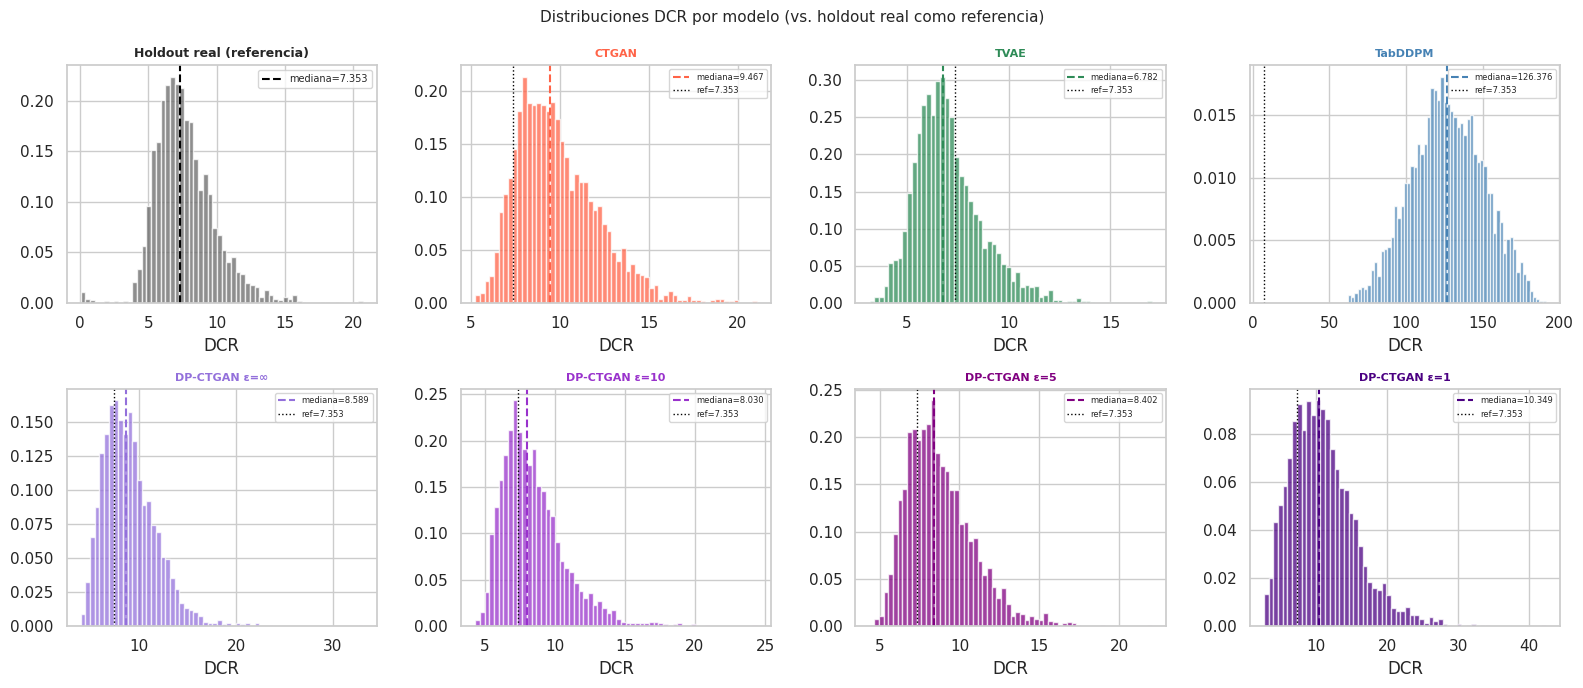

Guardado: reports/privacidad_dcr_distribuciones.png


In [5]:
# Figura: distribuciones DCR — sintético vs holdout de referencia
n_models = len(dcr_results)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes_flat = axes.flatten()

# Panel 0: holdout de referencia
ax = axes_flat[0]
ax.hist(dcr_holdout, bins=60, color='dimgray', alpha=0.75, density=True)
ax.axvline(np.median(dcr_holdout), color='black', linestyle='--', lw=1.5,
           label=f'mediana={np.median(dcr_holdout):.3f}')
ax.set_title('Holdout real (referencia)', fontsize=9, fontweight='bold')
ax.set_xlabel('DCR')
ax.legend(fontsize=7)

for i, (name, dcr) in enumerate(dcr_results.items(), start=1):
    ax = axes_flat[i]
    ax.hist(dcr, bins=60, color=COLORS.get(name, 'steelblue'), alpha=0.75, density=True)
    ax.axvline(np.median(dcr),        color=COLORS.get(name,'steelblue'), linestyle='--', lw=1.5,
               label=f'mediana={np.median(dcr):.3f}')
    ax.axvline(np.median(dcr_holdout), color='black', linestyle=':', lw=1.0,
               label=f'ref={np.median(dcr_holdout):.3f}')
    ax.set_title(name, fontsize=8, color=COLORS.get(name,'black'), fontweight='bold')
    ax.set_xlabel('DCR')
    ax.legend(fontsize=6)

# Ocultar panel sobrante si hay menos de 8 modelos
for j in range(n_models + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Distribuciones DCR por modelo (vs. holdout real como referencia)', fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS / 'privacidad_dcr_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/privacidad_dcr_distribuciones.png')

## 4. NNDR — Nearest Neighbor Distance Ratio

El NNDR cuantifica si una muestra sintética está "atrapada" cerca de un único registro real
(potencial memorización) o se ubica en una región del espacio entre varios registros (generalización):
$$\text{NNDR}(s) = \frac{d(s, \text{NN}_1)}{d(s, \text{NN}_2)}$$

Un NNDR cercano a 0 indica que un registro real está mucho más cerca que el siguiente
(riesgo de copia). Un NNDR cercano a 1 indica que la muestra sintética se sitúa en una
región de generalización entre varios registros reales.

In [6]:
def compute_nndr(X_query, X_reference, n_sub=N_SUB, seed=42):
    """Nearest Neighbor Distance Ratio = d(NN1) / d(NN2)."""
    rng = np.random.default_rng(seed)
    if len(X_query) > n_sub:
        idx = rng.choice(len(X_query), n_sub, replace=False)
        X_query = X_query[idx]
    nn = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', n_jobs=-1)
    nn.fit(X_reference)
    dist, _ = nn.kneighbors(X_query)
    d1, d2  = dist[:, 0], dist[:, 1]
    # Si d2 es cero (duplicado exacto), NNDR = 0 (riesgo máximo)
    nndr = np.where(d2 > 1e-10, d1 / d2, 0.0)
    return nndr


nndr_holdout = compute_nndr(X_ref_holdout_s, X_ref_train_s)

print('=== NNDR — Nearest Neighbor Distance Ratio ===\n')
print(f'  Holdout real (referencia)')
print(f'    mediana={np.median(nndr_holdout):.4f}  % NNDR<0.5={((nndr_holdout<0.5).mean()*100):.1f}%\n')

nndr_results = {}
for name, X_s in synth_scaled.items():
    nndr = compute_nndr(X_s, X_real_s)
    nndr_results[name] = nndr
    pct_low  = (nndr < 0.5).mean() * 100
    pct_vlow = (nndr < 0.2).mean() * 100
    print(f'  {name:<20}  mediana={np.median(nndr):.4f}  '
          f'% NNDR<0.5={pct_low:.1f}%  % NNDR<0.2 (alto riesgo)={pct_vlow:.1f}%')

=== NNDR — Nearest Neighbor Distance Ratio ===

  Holdout real (referencia)
    mediana=0.9737  % NNDR<0.5=0.1%

  CTGAN                 mediana=0.9869  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  TVAE                  mediana=0.9775  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  TabDDPM               mediana=0.9822  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  DP-CTGAN ε=∞          mediana=0.9746  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  DP-CTGAN ε=10         mediana=0.9845  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  DP-CTGAN ε=5          mediana=0.9873  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%
  DP-CTGAN ε=1          mediana=0.9931  % NNDR<0.5=0.0%  % NNDR<0.2 (alto riesgo)=0.0%


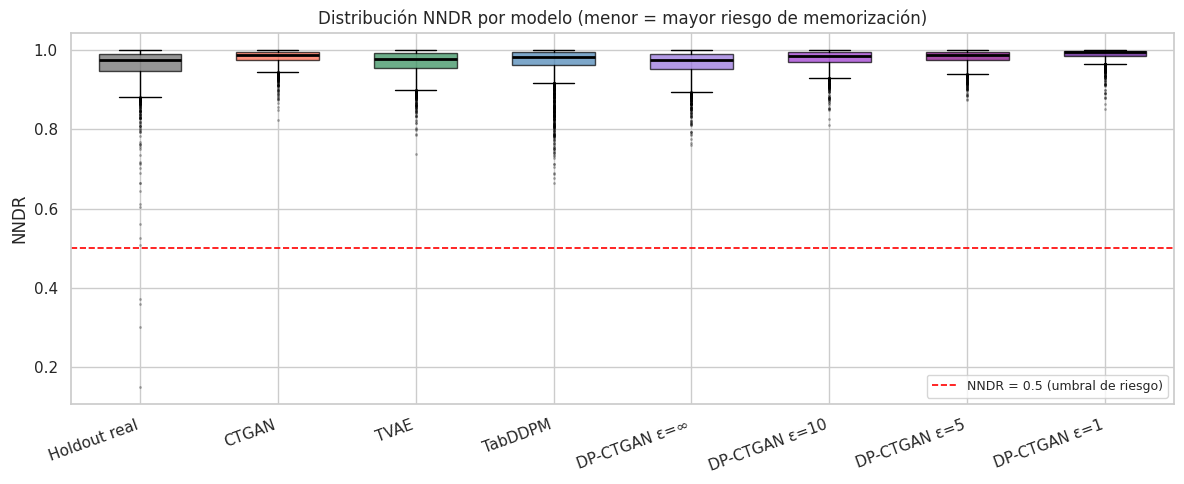

Guardado: reports/privacidad_nndr_boxplot.png


In [7]:
# Figura: boxplots NNDR comparados
all_names = ['Holdout real'] + list(nndr_results.keys())
all_nndr  = [nndr_holdout] + list(nndr_results.values())

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(
    all_nndr,
    labels=all_names,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
    widths=0.6,
)
colors_list = [COLORS.get(n, 'steelblue') for n in all_names]
for patch, c in zip(bp['boxes'], colors_list):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.axhline(0.5, color='red', linestyle='--', lw=1.2, label='NNDR = 0.5 (umbral de riesgo)')
ax.set_ylabel('NNDR')
ax.set_title('Distribución NNDR por modelo (menor = mayor riesgo de memorización)')
ax.legend(fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(REPORTS / 'privacidad_nndr_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/privacidad_nndr_boxplot.png')

## 5. MIA — Membership Inference Advantage

La ventaja de inferencia de pertenencia mide si las muestras sintéticas están más cerca del
conjunto de referencia de entrenamiento que del holdout, lo que indicaría que el generador
ha memorizado información del dataset original:

$$\text{MIA-adv} = P\!\left(d(s,\,\mathcal{D}_{\text{train}}) < d(s,\,\mathcal{D}_{\text{holdout}}) \mid s \in \mathcal{D}_{\text{synth}}\right) - 0{,}5$$

- MIA-adv $\approx 0$: privacidad correcta — los datos sintéticos no están más cerca del training
  que de datos genuinamente nuevos.
- MIA-adv $> 0$: los datos sintéticos se aproximan más al training, lo que sugiere filtración.
- La referencia es el holdout real, cuyo MIA-adv debe ser próximo a 0 (o negativo) si el
  modelo de entrenamiento no ha sobreajustado.

In [8]:
def mia_advantage(X_query, X_train_ref, X_holdout_ref, n_sub=N_SUB, seed=42):
    """
    Membership Inference Advantage basado en distancias.
    Para cada muestra en X_query: ¿es más cercana a X_train_ref que a X_holdout_ref?
    Devuelve (advantage, fraccion_mas_cerca_train).
    """
    rng = np.random.default_rng(seed)
    if len(X_query) > n_sub:
        idx = rng.choice(len(X_query), n_sub, replace=False)
        X_query = X_query[idx]

    nn_tr = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', n_jobs=-1)
    nn_tr.fit(X_train_ref)
    d_tr, _ = nn_tr.kneighbors(X_query)

    nn_ho = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', n_jobs=-1)
    nn_ho.fit(X_holdout_ref)
    d_ho, _ = nn_ho.kneighbors(X_query)

    p_closer_train = float((d_tr[:, 0] < d_ho[:, 0]).mean())
    advantage      = p_closer_train - 0.5
    return advantage, p_closer_train


# Referencia: MIA del holdout real
# Dividir holdout en dos mitades para evitar comparación consigo mismo
rng_ref    = np.random.default_rng(0)
n_half     = len(X_ref_holdout_s) // 2
perm_hold  = rng_ref.permutation(len(X_ref_holdout_s))
X_hold_A   = X_ref_holdout_s[perm_hold[:n_half]]
X_hold_B   = X_ref_holdout_s[perm_hold[n_half:]]
adv_ref, p_ref = mia_advantage(X_hold_A, X_ref_train_s, X_hold_B, n_sub=len(X_hold_A))

print('=== MIA — Membership Inference Advantage ===\n')
print(f'  Referencia (holdout real):  advantage={adv_ref:+.4f}  P(cerca train)={p_ref:.4f}')
print(f'  Interpretación: muestras reales no vistas en entrenamiento tienen advantage={adv_ref:+.4f}\n')

mia_results = {}
for name, X_s in synth_scaled.items():
    adv, p_train = mia_advantage(X_s, X_ref_train_s, X_ref_holdout_s)
    mia_results[name] = {'advantage': adv, 'p_closer_train': p_train}
    delta = adv - adv_ref
    risk  = 'bajo' if abs(delta) < 0.05 else ('moderado' if abs(delta) < 0.15 else 'alto')
    print(f'  {name:<20}  advantage={adv:+.4f}  '
          f'P(cerca train)={p_train:.4f}  Δ vs ref={delta:+.4f}  riesgo={risk}')

=== MIA — Membership Inference Advantage ===

  Referencia (holdout real):  advantage=+0.3903  P(cerca train)=0.8903
  Interpretación: muestras reales no vistas en entrenamiento tienen advantage=+0.3903

  CTGAN                 advantage=+0.2710  P(cerca train)=0.7710  Δ vs ref=-0.1193  riesgo=moderado
  TVAE                  advantage=+0.2970  P(cerca train)=0.7970  Δ vs ref=-0.0933  riesgo=moderado
  TabDDPM               advantage=+0.1993  P(cerca train)=0.6993  Δ vs ref=-0.1910  riesgo=alto
  DP-CTGAN ε=∞          advantage=+0.3000  P(cerca train)=0.8000  Δ vs ref=-0.0903  riesgo=moderado
  DP-CTGAN ε=10         advantage=+0.2840  P(cerca train)=0.7840  Δ vs ref=-0.1063  riesgo=moderado
  DP-CTGAN ε=5          advantage=+0.2740  P(cerca train)=0.7740  Δ vs ref=-0.1163  riesgo=moderado
  DP-CTGAN ε=1          advantage=+0.2213  P(cerca train)=0.7213  Δ vs ref=-0.1690  riesgo=alto


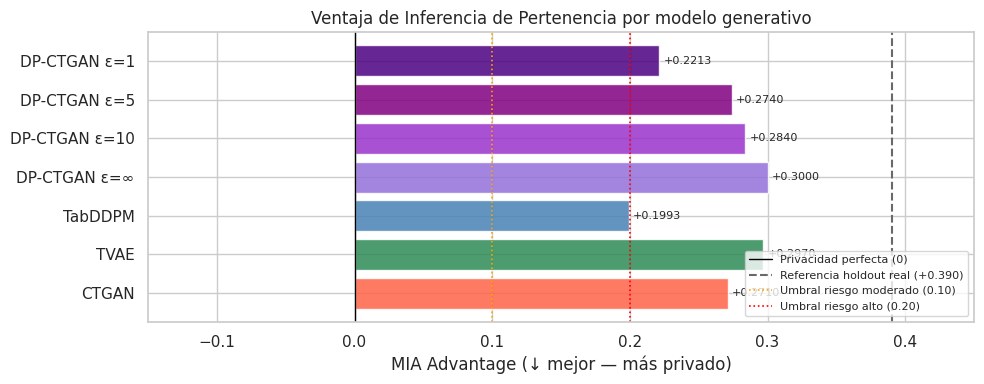

Guardado: reports/privacidad_mia_advantage.png


In [9]:
# Figura: MIA advantage por modelo
model_names = list(mia_results.keys())
advantages  = [mia_results[m]['advantage'] for m in model_names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(model_names, advantages,
               color=[COLORS.get(m, 'steelblue') for m in model_names],
               alpha=0.85)
ax.axvline(0.0,    color='black',  linestyle='-',  lw=1.0, label='Privacidad perfecta (0)')
ax.axvline(adv_ref, color='dimgray', linestyle='--', lw=1.5,
           label=f'Referencia holdout real ({adv_ref:+.3f})')
ax.axvline(0.1,    color='orange', linestyle=':', lw=1.2, label='Umbral riesgo moderado (0.10)')
ax.axvline(0.2,    color='red',    linestyle=':', lw=1.2, label='Umbral riesgo alto (0.20)')

for i, (name, v) in enumerate(zip(model_names, advantages)):
    ax.text(v + 0.003, i, f'{v:+.4f}', va='center', fontsize=8)

ax.set_xlabel('MIA Advantage (↓ mejor — más privado)')
ax.set_title('Ventaja de Inferencia de Pertenencia por modelo generativo')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(-0.15, 0.45)
plt.tight_layout()
plt.savefig(REPORTS / 'privacidad_mia_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/privacidad_mia_advantage.png')

## 6. Tradeoff Privacidad–Utilidad

Se visualiza la frontera de Pareto entre utilidad analítica (AUROC TSTR de nb09)
y riesgo de privacidad (MIA advantage de este notebook).
El modelo ideal se sitúa en la esquina inferior derecha: alta utilidad y bajo riesgo.
Las variantes DP-CTGAN permiten trazar la curva de tradeoff al variar ε.

In [10]:
# Cargar AUROC de utilidad desde nb09
util_csv = REPORTS / 'utilidad_summary.csv'
if util_csv.exists():
    utility_df = pd.read_csv(util_csv, index_col=0)
    tstr_rows  = utility_df[utility_df['Protocolo'] == 'TSTR']
    auroc_map  = tstr_rows['AUROC'].to_dict()
    print('AUROC de utilidad cargados desde utilidad_summary.csv:')
    for m, v in auroc_map.items():
        print(f'  {m:<20} AUROC={v:.4f}')
else:
    print('AVISO: utilidad_summary.csv no encontrado. Ejecuta nb09 primero.')
    auroc_map = {}

print()

# Tabla combinada privacidad–utilidad
print(f'{"Modelo":<22} {"AUROC util":>10} {"MIA adv":>10} {"DCR med":>10} {"NNDR med":>10}')
print('-' * 68)
for name in mia_results:
    auroc  = auroc_map.get(name, float('nan'))
    adv    = mia_results[name]['advantage']
    dcr_m  = np.median(dcr_results[name]) if name in dcr_results else float('nan')
    nndr_m = np.median(nndr_results[name]) if name in nndr_results else float('nan')
    print(f'{name:<22} {auroc:>10.4f} {adv:>10.4f} {dcr_m:>10.4f} {nndr_m:>10.4f}')

AUROC de utilidad cargados desde utilidad_summary.csv:
  CTGAN                AUROC=0.7775
  TVAE                 AUROC=0.8352
  TabDDPM              AUROC=0.7797
  DP-CTGAN ε=∞         AUROC=0.7442
  DP-CTGAN ε=10        AUROC=0.6919
  DP-CTGAN ε=5         AUROC=0.7128
  DP-CTGAN ε=1         AUROC=0.6628

Modelo                 AUROC util    MIA adv    DCR med   NNDR med
--------------------------------------------------------------------
CTGAN                      0.7775     0.2710     9.4670     0.9869
TVAE                       0.8352     0.2970     6.7817     0.9775
TabDDPM                    0.7797     0.1993   126.3761     0.9822
DP-CTGAN ε=∞               0.7442     0.3000     8.5892     0.9746
DP-CTGAN ε=10              0.6919     0.2840     8.0303     0.9845
DP-CTGAN ε=5               0.7128     0.2740     8.4020     0.9873
DP-CTGAN ε=1               0.6628     0.2213    10.3493     0.9931


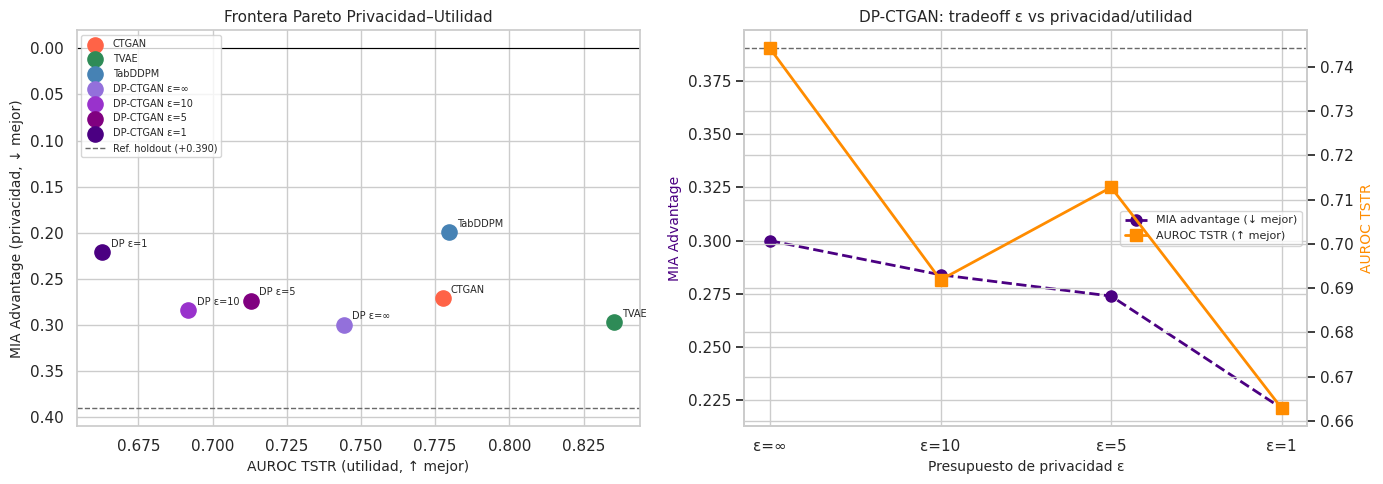

Guardado: reports/privacidad_pareto_tradeoff.png


In [11]:
# Figura: Pareto frontier privacidad-utilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Pareto frontier (todos los modelos)
ax = axes[0]
for name in mia_results:
    auroc = auroc_map.get(name, None)
    adv   = mia_results[name]['advantage']
    if auroc is None:
        continue
    ax.scatter(auroc, adv, color=COLORS.get(name, 'gray'),
               s=120, zorder=5, label=name)
    ax.annotate(name.replace('DP-CTGAN ', 'DP '),
                (auroc, adv), textcoords='offset points',
                xytext=(6, 4), fontsize=7)

ax.axhline(adv_ref, color='dimgray', linestyle='--', lw=1.0,
           label=f'Ref. holdout ({adv_ref:+.3f})')
ax.axhline(0.0,     color='black',   linestyle='-',  lw=0.8)
ax.set_xlabel('AUROC TSTR (utilidad, ↑ mejor)', fontsize=10)
ax.set_ylabel('MIA Advantage (privacidad, ↓ mejor)', fontsize=10)
ax.set_title('Frontera Pareto Privacidad–Utilidad', fontsize=11)
ax.legend(fontsize=7, loc='upper left')
ax.invert_yaxis()  # eje Y invertido: más bajo = más privado = mejor

# Panel derecho: curva ε–utilidad y ε–privacidad para DP-CTGAN
ax2 = axes[1]
dp_models = [(m, mia_results[m]['advantage'], auroc_map.get(m, float('nan')))
             for m in ['DP-CTGAN ε=∞', 'DP-CTGAN ε=10', 'DP-CTGAN ε=5', 'DP-CTGAN ε=1']
             if m in mia_results]

eps_labels = [m[0].replace('DP-CTGAN ', '') for m in dp_models]
mia_vals   = [m[1] for m in dp_models]
auroc_vals = [m[2] for m in dp_models]

x = np.arange(len(eps_labels))
ax2l = ax2
ax2r = ax2.twinx()

ax2l.plot(x, mia_vals,   'o--', color='indigo',    lw=2, ms=8, label='MIA advantage (↓ mejor)')
ax2r.plot(x, auroc_vals, 's-',  color='darkorange', lw=2, ms=8, label='AUROC TSTR (↑ mejor)')

ax2l.set_xticks(x)
ax2l.set_xticklabels(eps_labels)
ax2l.set_xlabel('Presupuesto de privacidad ε', fontsize=10)
ax2l.set_ylabel('MIA Advantage', fontsize=10, color='indigo')
ax2r.set_ylabel('AUROC TSTR',    fontsize=10, color='darkorange')
ax2l.set_title('DP-CTGAN: tradeoff ε vs privacidad/utilidad', fontsize=11)
ax2l.axhline(adv_ref, color='dimgray', linestyle='--', lw=1.0)

lines1, labels1 = ax2l.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2l.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

plt.tight_layout()
plt.savefig(REPORTS / 'privacidad_pareto_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/privacidad_pareto_tradeoff.png')

## 7. Tabla resumen y exportación

In [12]:
print('=== TABLA RESUMEN DE PRIVACIDAD ===\n')

rows = []
# Fila de referencia (holdout real)
rows.append({
    'Modelo':           'Holdout real (ref.)',
    'DCR mediana':      np.median(dcr_holdout),
    'DCR p5':           np.percentile(dcr_holdout, 5),
    'NNDR mediana':     np.median(nndr_holdout),
    '% NNDR<0.5':       (nndr_holdout < 0.5).mean() * 100,
    'MIA advantage':    adv_ref,
    'AUROC TSTR':       float('nan'),
})

for name in mia_results:
    dcr   = dcr_results.get(name,  np.array([float('nan')]))
    nndr  = nndr_results.get(name, np.array([float('nan')]))
    adv   = mia_results[name]['advantage']
    auroc = auroc_map.get(name, float('nan'))
    rows.append({
        'Modelo':           name,
        'DCR mediana':      np.median(dcr),
        'DCR p5':           np.percentile(dcr, 5),
        'NNDR mediana':     np.median(nndr),
        '% NNDR<0.5':       (nndr < 0.5).mean() * 100,
        'MIA advantage':    adv,
        'AUROC TSTR':       auroc,
    })

privacy_df = pd.DataFrame(rows).set_index('Modelo')
print(privacy_df.round(4).to_string())

privacy_df.to_csv(REPORTS / 'privacidad_summary.csv')
print('\nGuardado: reports/privacidad_summary.csv')

# Tabla LaTeX
latex_str = privacy_df.round(4).to_latex(
    caption='Métricas de privacidad por modelo generativo. '
            'DCR y NNDR calculados contra el dataset real completo. '
            'MIA advantage: fracción de muestras sintéticas más cercanas al training '
            'que al holdout, menos 0,5 (0 = sin ventaja inferencial).',
    label='tab:privacidad_summary',
    bold_rows=False,
    escape=True,
    na_rep='---',
)
(REPORTS / 'privacidad_summary_latex.tex').write_text(latex_str, encoding='utf-8')
print('Tabla LaTeX guardada: reports/privacidad_summary_latex.tex')
print()
print(latex_str)

=== TABLA RESUMEN DE PRIVACIDAD ===

                     DCR mediana   DCR p5  NNDR mediana  % NNDR<0.5  MIA advantage  AUROC TSTR
Modelo                                                                                        
Holdout real (ref.)       7.3533   4.9200        0.9737      0.1333         0.3903         NaN
CTGAN                     9.4670   6.7929        0.9869      0.0000         0.2710      0.7775
TVAE                      6.7817   4.8106        0.9775      0.0000         0.2970      0.8352
TabDDPM                 126.3761  87.8109        0.9822      0.0000         0.1993      0.7797
DP-CTGAN ε=∞              8.5892   5.3818        0.9746      0.0000         0.3000      0.7442
DP-CTGAN ε=10             8.0303   5.6403        0.9845      0.0000         0.2840      0.6919
DP-CTGAN ε=5              8.4020   6.0182        0.9873      0.0000         0.2740      0.7128
DP-CTGAN ε=1             10.3493   4.6122        0.9931      0.0000         0.2213      0.6628

Guardado: re

In [13]:
print('=' * 60)
print('  RESUMEN — Notebook 10 (Privacidad)')
print('=' * 60)
print(f'  Referencia holdout:  DCR med={np.median(dcr_holdout):.4f}  '
      f'NNDR med={np.median(nndr_holdout):.4f}  MIA adv={adv_ref:+.4f}')
print()
for name in mia_results:
    dcr_m  = np.median(dcr_results.get(name, [float('nan')]))
    nndr_m = np.median(nndr_results.get(name, [float('nan')]))
    adv    = mia_results[name]['advantage']
    auroc  = auroc_map.get(name, float('nan'))
    print(f'  {name:<20}  DCR={dcr_m:.4f}  NNDR={nndr_m:.4f}  '
          f'MIA={adv:+.4f}  AUROC={auroc:.4f}')
print('=' * 60)
print('Fase 3 completada. Listo para redacción de §5.3.')

  RESUMEN — Notebook 10 (Privacidad)
  Referencia holdout:  DCR med=7.3533  NNDR med=0.9737  MIA adv=+0.3903

  CTGAN                 DCR=9.4670  NNDR=0.9869  MIA=+0.2710  AUROC=0.7775
  TVAE                  DCR=6.7817  NNDR=0.9775  MIA=+0.2970  AUROC=0.8352
  TabDDPM               DCR=126.3761  NNDR=0.9822  MIA=+0.1993  AUROC=0.7797
  DP-CTGAN ε=∞          DCR=8.5892  NNDR=0.9746  MIA=+0.3000  AUROC=0.7442
  DP-CTGAN ε=10         DCR=8.0303  NNDR=0.9845  MIA=+0.2840  AUROC=0.6919
  DP-CTGAN ε=5          DCR=8.4020  NNDR=0.9873  MIA=+0.2740  AUROC=0.7128
  DP-CTGAN ε=1          DCR=10.3493  NNDR=0.9931  MIA=+0.2213  AUROC=0.6628
Fase 3 completada. Listo para redacción de §5.3.
